<a href="https://colab.research.google.com/github/amirkh96/cs666student/blob/main/CS666_Assignment_1_AmirhamzehKhoshnam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

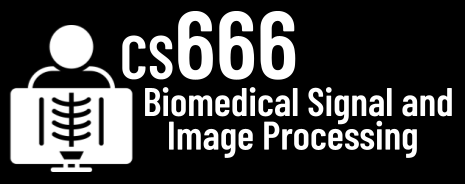

# Assignment 1

In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


**Task 1** (5 pts): Install the BioSPPY library with the following code.

In [2]:
!pip install biosppy

**Task 2** (10 pts): Download a sample ecg dataset from https://cs666.org/data/ecg.txt and upload it to this colab. The following code loads the dataset. Note: this might fail with an import error, but should be an easy fix :)

In [4]:

!pip -q install peakutils


In [5]:
from biosppy import storage
signal, metadata = storage.load_txt('ecg.txt')

**Task 3** (10 pts): Figure out the sampling rate for this data and how many seconds it lasts.

In [7]:

len(signal)

15000

In [8]:
SAMPLING_RATE = 1000
SECONDS = len(signal)/1000 ### TODO!

print(SAMPLING_RATE, SECONDS)

1000 15.0


**Task 4** (15 pts): Process the signal with BioSPPY using the `ecg.ecg` method.

In [ ]:
### TODO

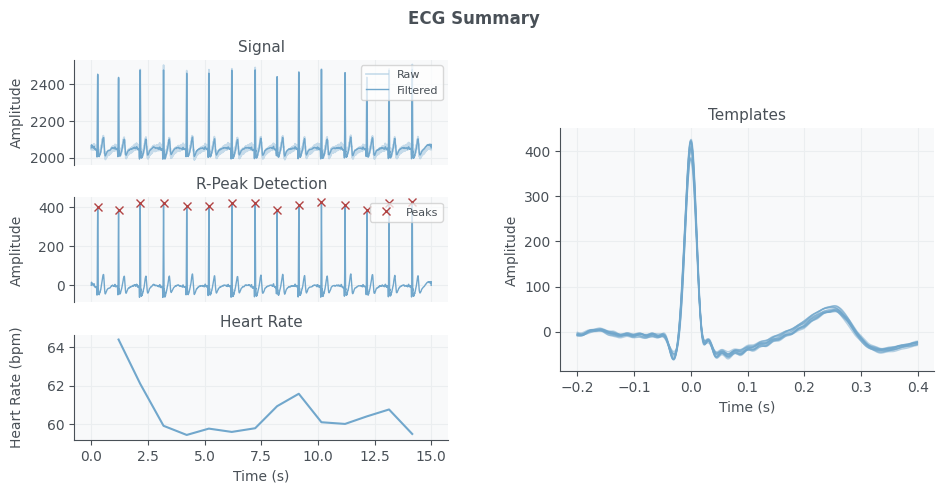

In [11]:

from biosppy.signals import ecg
out = ecg.ecg(signal=signal, sampling_rate=SAMPLING_RATE, show=True)


**Task 5** (10 pts): Plot the first 3 seconds of the unfiltered signal and then the filtered signal. Can you spot the P, Q, R, S, T waves?

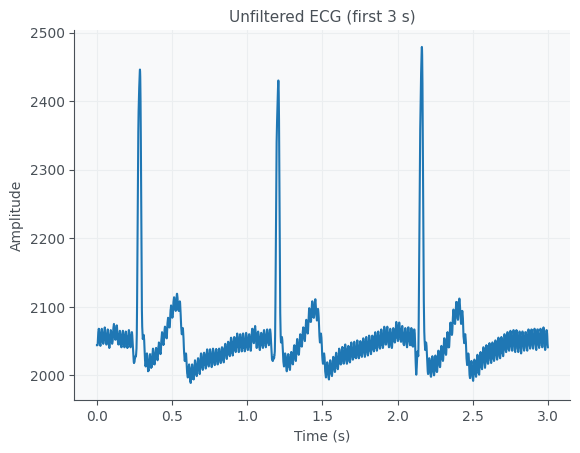

In [12]:
### TODO plot unfiltered signal
import matplotlib.pyplot as plt
import numpy as np

# run biosppy (filtered signal comes from here)
out = ecg.ecg(signal=signal, sampling_rate=SAMPLING_RATE, show=False)
xf = out["filtered"]

n = int(3 * SAMPLING_RATE)
t = np.arange(n) / SAMPLING_RATE

# Unfiltered (raw)
plt.figure()
plt.plot(t, signal[:n])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Unfiltered ECG (first 3 s)")
plt.show()




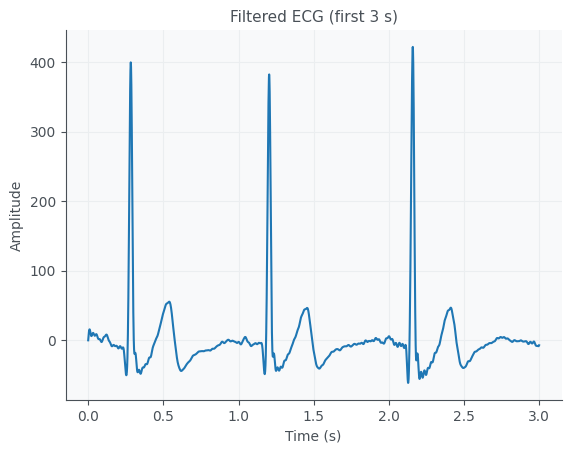

In [13]:
### TODO plot filtered signal

# Filtered
plt.figure()
plt.plot(t, xf[:n])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Filtered ECG (first 3 s)")
plt.show()

**Task 6** (15 pts): Please plot the whole filtered signal and mark the r-peaks with vertical lines based on the ecg.ecg output. You can use `plt.axvline(x = 100, color = 'r', ls=':')` to create a red, dashed vertical line at position 100. Please label the x-axis as 'time [s]'.

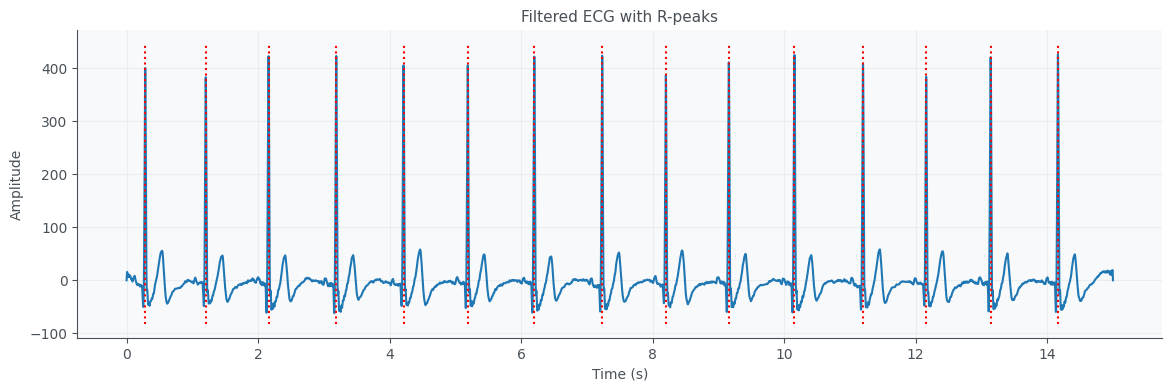

In [23]:


ts = out["ts"]
filt = out["filtered"]
rpeaks = out["rpeaks"]

plt.figure(figsize=(14, 4))
plt.plot(ts, filt)
plt.vlines(ts[rpeaks], ymin=filt.min() - 20, ymax=filt.max()+ 20, color = 'r',ls = ':')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Filtered ECG with R-peaks")
plt.show()


**Task 7** (5 pts): Let's install the NeuroKit2 library.

In [14]:
!pip install neurokit2
import neurokit2 as nk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 12.2 MB/s eta 0:00:00


**Task 8** (20 pts): Detect P Q S T Peaks using Neurokit.

In [ ]:
# We know the R spikes now but what about P Q S T waves?
# TODO Can you use nk.ecg_delineate to detect them in the unfiltred signal?
# Hint: Look at the tutorial: https://neuropsychology.github.io/NeuroKit/examples/ecg_delineate/ecg_delineate.html
# Hint 2: The plot will have blue, orange, green, and red circles :)
# Hint 3: rpeaks were detected above from biosppy's ecg.ecg method

In [30]:
# TODO Does the detection work well?

sig_clean = nk.ecg_clean(signal, sampling_rate=SAMPLING_RATE)
_, waves = nk.ecg_delineate(sig_clean, rpeaks={"ECG_R_Peaks": rpeaks},
                            sampling_rate=SAMPLING_RATE, method="dwt")


Detected peaks: P 14 Q 14 S 14 T 14


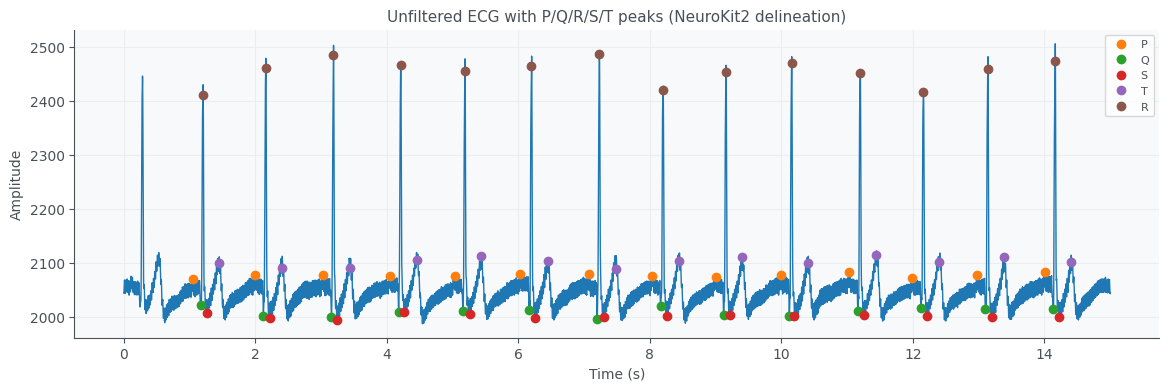

In [28]:

# NeuroKit expects rpeaks as a dict: {"ECG_R_Peaks": ...}
_, waves = nk.ecg_delineate(
    signal,
    rpeaks={"ECG_R_Peaks": rpeaks},
    sampling_rate=SAMPLING_RATE,
    method="dwt"
)

# Extract indices (may contain NaNs)
P = np.asarray(waves["ECG_P_Peaks"])
Q = np.asarray(waves["ECG_Q_Peaks"])
S = np.asarray(waves["ECG_S_Peaks"])
T = np.asarray(waves["ECG_T_Peaks"])

# Keep only valid integer indices
def clean_idx(arr):
    arr = arr[~np.isnan(arr)].astype(int)
    return arr[(arr >= 0) & (arr < len(signal))]

P, Q, S, T = map(clean_idx, [P, Q, S, T])

print("Detected peaks:", "P", len(P), "Q", len(Q), "S", len(S), "T", len(T))

# Plot (full signal) + colored circles
t = np.arange(len(signal)) / SAMPLING_RATE
plt.figure(figsize=(14,4))
plt.plot(t, signal, linewidth=1)

plt.plot(t[P], signal[P], "o", label="P")
plt.plot(t[Q], signal[Q], "o", label="Q")
plt.plot(t[S], signal[S], "o", label="S")
plt.plot(t[T], signal[T], "o", label="T")

plt.plot(t[rpeaks], signal[rpeaks], "o", label="R")  # use circle for peaks to make more alignment

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Unfiltered ECG with P/Q/R/S/T peaks (NeuroKit2 delineation)")
plt.legend()
plt.show()

**Task 9** (10 pts): Use the sleepecg library to find the R Peaks.

In [ ]:
# We have the R spikes/peaks now from Biosppy from above but there is another
# library called sleepecg.
# TODO Please install it and run the rpeak detection!
# Docs: https://sleepecg.readthedocs.io/en/stable/

In [ ]:
# TODO Do Biosppy and sleepecg give different rpeaks? Please calculate the MSE!

BioSPPy peaks: 15
sleepECG peaks: 15


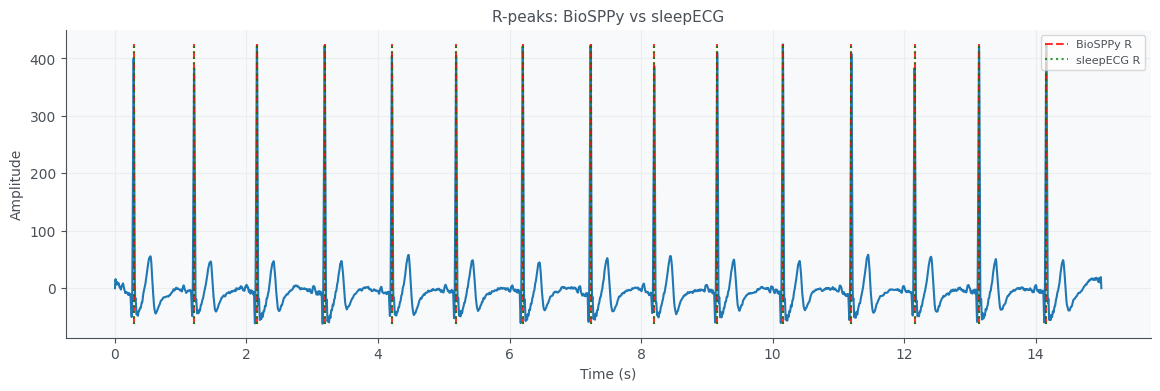

In [33]:


!pip -q install sleepecg
import sleepecg

sig = np.asarray(signal).squeeze()
Fs = SAMPLING_RATE

# 1) R-peaks from sleepECG
# returns peak locations in samples
r_sleep = sleepecg.detect_heartbeats(sig, fs=Fs)
r_sleep = np.asarray(r_sleep, dtype=int)

# 2) R-peaks from BioSPPy (you already have these)
r_bios = np.asarray(out["rpeaks"], dtype=int)

print("BioSPPy peaks:", len(r_bios))
print("sleepECG peaks:", len(r_sleep))

# 3) Compare peaks: align by time using nearest-neighbor matching, then compute MSE (in samples^2)
def nearest_match_mse(a, b):
    a = np.sort(np.asarray(a, dtype=int))
    b = np.sort(np.asarray(b, dtype=int))
    if len(a) == 0 or len(b) == 0:
        return np.nan
    # for each a, find closest b
    idx = np.searchsorted(b, a)
    idx0 = np.clip(idx - 1, 0, len(b) - 1)
    idx1 = np.clip(idx,     0, len(b) - 1)
    d0 = np.abs(a - b[idx0])
    d1 = np.abs(a - b[idx1])
    d = np.minimum(d0, d1)
    return np.mean(d.astype(float)**2)


# plot of the peaks
plt.figure(figsize=(14,4))
plt.plot(ts, filt)
plt.vlines(ts[r_bios], ymin=filt.min(), ymax=filt.max(), colors="red", linestyles="--", alpha=0.8, label="BioSPPy R")
plt.vlines(ts[r_sleep], ymin=filt.min(), ymax=filt.max(), colors="green", linestyles=":", alpha=0.8, label="sleepECG R")
plt.title("R-peaks: BioSPPy vs sleepECG")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


In [32]:

mse_samples2 = nearest_match_mse(r_bios, r_sleep)
mse_ms2 = mse_samples2 * (1000.0/Fs)**2  # convert (samples^2) -> (ms^2)

print(f"MSE (samples^2): {mse_samples2:.3f}")
print(f"MSE (ms^2):      {mse_ms2:.3f}")

MSE (samples^2): 0.200
MSE (ms^2):      0.200


**They found similar peaks**

**Bonus Task** (33 pts): Detect P Q S T Peaks for the full signal before and after filtering.

In [34]:
Fs = SAMPLING_RATE
sig_raw = np.asarray(signal).squeeze()

# R-peaks from BioSPPy (do NOT recompute)
rpeaks = np.asarray(out["rpeaks"], dtype=int)
rdict = {"ECG_R_Peaks": rpeaks}

def extract_peaks(waves, n):
    def clean(arr):
        arr = np.asarray(arr, dtype=float)
        arr = arr[~np.isnan(arr)].astype(int)
        return arr[(arr >= 0) & (arr < n)]
    return {
        "P": clean(waves.get("ECG_P_Peaks", [])),
        "Q": clean(waves.get("ECG_Q_Peaks", [])),
        "S": clean(waves.get("ECG_S_Peaks", [])),
        "T": clean(waves.get("ECG_T_Peaks", [])),
    }

# 1) Delineation on UNFILTERED signal
_, waves_raw = nk.ecg_delineate(sig_raw, rpeaks=rdict, sampling_rate=Fs, method="dwt")
peaks_raw = extract_peaks(waves_raw, len(sig_raw))
print("UNFILTERED counts:", {k: len(v) for k, v in peaks_raw.items()})

# 2) Bandpass filter with NeuroKit and delineate (play with lowcut/highcut)
sig_bp = nk.signal_filter(sig_raw, sampling_rate=Fs, lowcut=0.5, highcut=40, method="butterworth", order=4)
_, waves_bp = nk.ecg_delineate(sig_bp, rpeaks=rdict, sampling_rate=Fs, method="dwt")
peaks_bp = extract_peaks(waves_bp, len(sig_bp))
print("NK bandpass counts:", {k: len(v) for k, v in peaks_bp.items()})

# 3) Delineation on BioSPPy filtered signal
sig_bios = np.asarray(out["filtered"]).squeeze()
_, waves_bios = nk.ecg_delineate(sig_bios, rpeaks=rdict, sampling_rate=Fs, method="dwt")
peaks_bios = extract_peaks(waves_bios, len(sig_bios))
print("BioSPPy filtered counts:", {k: len(v) for k, v in peaks_bios.items()})

UNFILTERED counts: {'P': 14, 'Q': 14, 'S': 15, 'T': 15}
NK bandpass counts: {'P': 14, 'Q': 15, 'S': 15, 'T': 15}
BioSPPy filtered counts: {'P': 14, 'Q': 15, 'S': 15, 'T': 15}


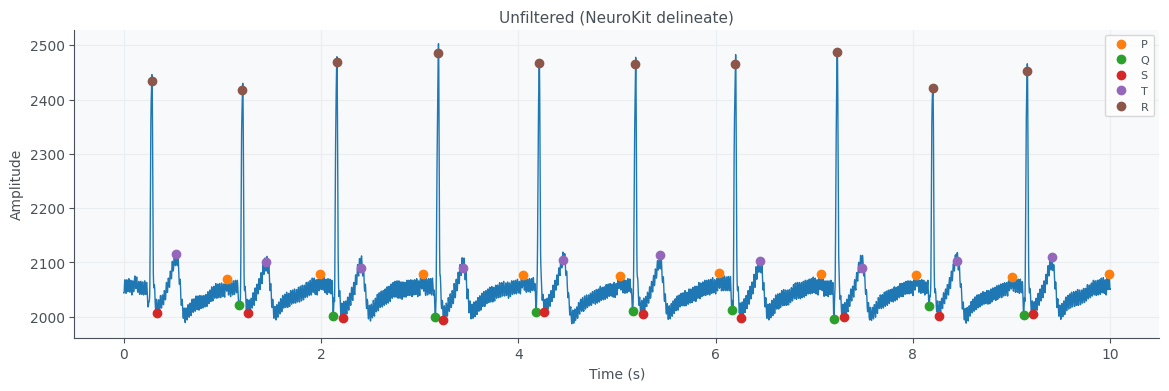

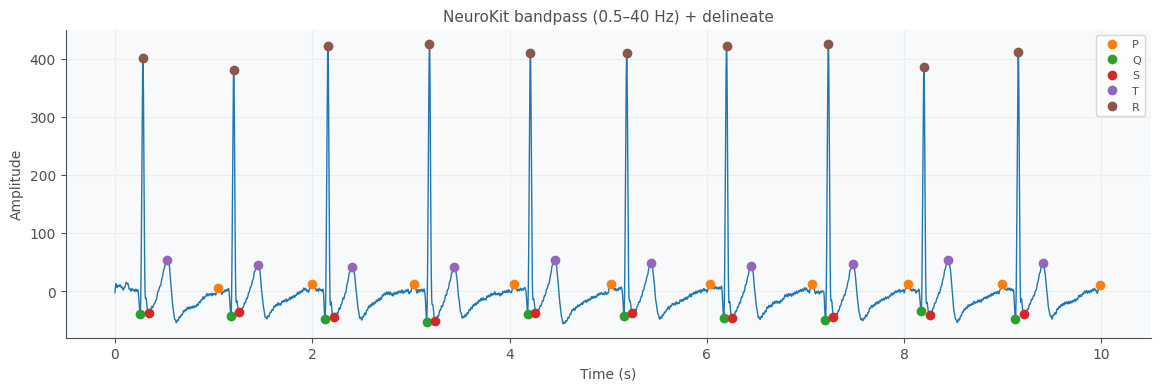

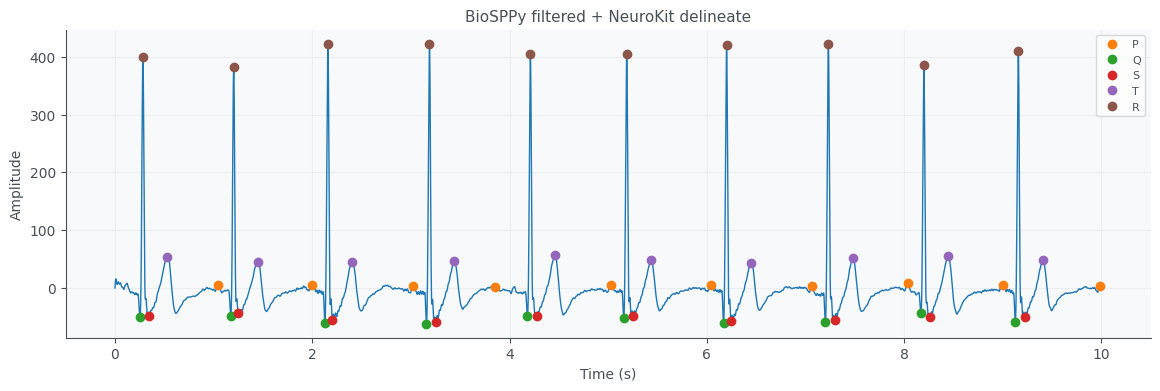

In [35]:

t = np.arange(len(sig_raw)) / Fs
sec = 10
n = int(sec * Fs)

def plot_panel(sig, peaks, title):
    plt.figure(figsize=(14,4))
    plt.plot(t[:n], sig[:n], linewidth=1)
    for lab in ["P","Q","S","T"]:
        idx = peaks[lab]
        idx = idx[idx < n]
        plt.plot(t[idx], sig[idx], "o", label=lab)
    plt.plot(t[rpeaks[rpeaks < n]], sig[rpeaks[rpeaks < n]], "o", label="R")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

plot_panel(sig_raw,  peaks_raw,  "Unfiltered (NeuroKit delineate)")
plot_panel(sig_bp,   peaks_bp,   "NeuroKit bandpass (0.5–40 Hz) + delineate")
plot_panel(sig_bios, peaks_bios, "BioSPPy filtered + NeuroKit delineate")

In [ ]:
# TODO As above use the nk.ecg_delineate function to detect peaks for the whole signal

In [ ]:
# TODO Let's filter the signal and see if the detection improves.
# Hint: You can use nk.signal_filter to define a bandpass.
# Hint 2: Which lowcut and highcut frequencies work well? Play with it :)
# Hint 3: You don't need to re-calculate the rpeaks since they are pretty accurate in general.

In [ ]:
# Finally, run the delineation on the filtered signal from BioSPPY.

In [ ]:
# TODO Which one works the best?

They are all looks the same

In [ ]:
#
# Great job!!
#
#  , ; ,   .-'"""'-.   , ; ,
#  \\|/  .'         '.  \|//
#   \-;-/   ()   ()   \-;-/
#   // ;               ; \\
#  //__; :.         .; ;__\\
# `-----\'.'-.....-'.'/-----'
#        '.'.-.-,_.'.'
#jgs       '(  (..-'
#            '-'
#